# Setup GTEx data
## Confirm low batch effects
### Author: Martin Loza
### Date: 25/12/18

After selecting the window and genes of interest, we will setup gene pairs for co-expression analysis with ENCODE and GTEx data.

The first step is to compare batch effects and setup genes of interest. In this case we will focus only in genes with a related ENSEMBL ID

In [42]:
# Change R language to English
Sys.setenv(LANGUAGE = "en")

# Init
suppressPackageStartupMessages({
    library(dplyr)
    library(stringr)
    library(ggplot2)
    library(patchwork)
    library(sva)
    library(umap)
})

# Local variables 
seed = 777
date = "251216"

# Define colors for strand plots
red = "#E41A1C"
blue = "#090a0bff"
# Define colors for gene types
green = "#4DAF4A"
purple = "#984EA3"
text_size = 18
width = 18.6
dot_size = 4
line_size = 1.5
dpi = 300

data_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/Data/GTEx/normalized/"
out_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/07_GTEx_analyses/Plots/"

# Local Functions


### Load and setup the data

Load the merged normalized data

In [33]:
# load the merged normalized data
data_normalized <- read.table(paste0(data_dir, "log_normalized_tpm_251218.tsv"), 
                        header = TRUE, sep = "\t", stringsAsFactors = FALSE)

data_raw <- read.table(paste0(data_dir, "raw_tpm_251218.tsv"), 
                         header = TRUE, sep = "\t", stringsAsFactors = FALSE)
head(data_normalized)

,Name,Description,Adipose_Subcutaneous,Adipose_Visceral_Omentum,Adrenal_Gland,Artery_Aorta,Artery_Coronary,Artery_Tibial,Bladder,Brain_Amygdala,⋯,Spleen,Stomach,Stomach_Mixed_Cell,Stomach_Mucosa,Stomach_Muscularis,Testis,Thyroid,Uterus,Vagina,Whole_Blood
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000223972,DDX11L1,0.000000,0.000000,0.00000000,0.000000,0.000000,0.000000,0.000000,0.00000000,⋯,0.000000,0.00000000,0.00000000,0.00000000,0.00000000,0.15507968,0.000000,0.000000,0.000000,0.000000
2,ENSG00000227232,WASH7P,1.609016,1.429869,1.30103055,1.623499,1.584217,1.531747,1.800214,0.89976290,⋯,1.951976,1.39653425,1.46532964,1.35422045,1.62642875,1.71244025,1.990325,2.087992,1.908337,1.359701
3,ENSG00000278267,MIR6859-1,0.000000,0.000000,0.00000000,0.000000,0.000000,0.000000,0.000000,0.00000000,⋯,0.000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.000000,0.000000,0.000000,0.000000
4,ENSG00000243485,MIR1302-2HG,0.000000,0.000000,0.00000000,0.000000,0.000000,0.000000,0.000000,0.00000000,⋯,0.000000,0.00000000,0.00000000,0.00000000,0.00000000,0.05345261,0.000000,0.000000,0.000000,0.000000
5,ENSG00000237613,FAM138A,0.000000,0.000000,0.00000000,0.000000,0.000000,0.000000,0.000000,0.00000000,⋯,0.000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.000000,0.000000,0.000000,0.000000
6,ENSG00000268020,OR4G4P,0.000000,0.000000,0.03514415,0.000000,0.000000,0.000000,0.000000,0.04319454,⋯,0.000000,0.03167404,0.03783225,0.03747303,0.06640225,0.00000000,0.000000,0.000000,0.000000,0.000000


Prepare the data

In [34]:
# Extract sample names from column names (remove "log_TPM_" prefix)
sample_names <- colnames(data_normalized)[-c(1,2)]  # Exclude gene_id column

cat("Number of samples:", length(sample_names), "\n")
head(sample_names)

Number of samples: 68 


[1] "Adipose_Subcutaneous"     "Adipose_Visceral_Omentum"
[3] "Adrenal_Gland"            "Artery_Aorta"            
[5] "Artery_Coronary"          "Artery_Tibial"

In [35]:
# Create a batch vector based on the experimental accession
# Each sample corresponds to one experiment (ENCSR ID)
# We'll match the sample names with the Accession column in metadata

batch_info <- data.frame(
  sample = sample_names,
  stringsAsFactors = FALSE
)

head(batch_info)
cat("\nNumber of (samples):", length(unique(batch_info$sample)), "\n")

,sample
,<chr>
1,Adipose_Subcutaneous
2,Adipose_Visceral_Omentum
3,Adrenal_Gland
4,Artery_Aorta
5,Artery_Coronary
6,Artery_Tibial



Number of (samples): 68 


### Compare TPM vs Log-normalized TPM

We will compare the raw TPM data with the log-normalized TPM data using:
1. PCA plots (PC1 vs PC2)
2. UMAP plots (using first 10 PCs)

This will help us understand the effect of log normalization on the data structure.

In [36]:
# Prepare expression matrices
# Raw TPM data
expr_matrix_raw <- as.matrix(data_raw[, -c(1,2)])  # Remove gene_id column
rownames(expr_matrix_raw) <- data_raw$gene_id

# Log-normalized TPM data
expr_matrix_log <- as.matrix(data_normalized[, -c(1,2)])  # Remove gene_id column
rownames(expr_matrix_log) <- data_normalized$gene_id

# Check the dimensions
cat("Expression matrix dimensions:\n")
cat("Genes:", nrow(expr_matrix_raw), "\n")
cat("Samples:", ncol(expr_matrix_raw), "\n")

Expression matrix dimensions:
Genes: 59033 
Samples: 68 


Let's remove genes with zero expression across samples

In [37]:
# remove genes with zero variance
var_raw <- apply(expr_matrix_raw, 1, var)
expr_matrix_raw <- expr_matrix_raw[var_raw > 0, ]
# remove genes with zero variance
# We use the same filter to keep consistency across comparisons
expr_matrix_log <- expr_matrix_log[var_raw > 0, ]

In [38]:
### PCA Analysis

#Perform PCA on both raw TPM and log-normalized TPM data
# PCA on raw TPM data
cat("Performing PCA on raw TPM data...\n")
pca_raw <- prcomp(t(expr_matrix_raw), scale. = FALSE, center = TRUE)

# PCA on log-normalized TPM data
cat("Performing PCA on log-normalized TPM data...\n")
pca_log <- prcomp(t(expr_matrix_log), scale. = FALSE, center = TRUE)
cat("\nPCA completed!\n")

Performing PCA on raw TPM data...
Performing PCA on log-normalized TPM data...

PCA completed!


### Create PCA Plots

In [89]:
# PCA plot for raw TPM data
pca_raw_df <- data.frame(
  PC1 = pca_raw$x[, 1],
  PC2 = pca_raw$x[, 2],
  sample = sample_names
)

var_explained_raw <- round(100 * summary(pca_raw)$importance[2, 1:2], 1)

set.seed(seed)
p1 <- ggplot(pca_raw_df, aes(x = PC1, y = PC2, label = sample_names)) +
  geom_point(size = dot_size, alpha = 0.7) +
  ggrepel::geom_text_repel(size = 2.5, max.overlaps = 20, show.legend = FALSE, force = 10) +
  labs(
    title = "GTEx - Raw TPM",
    x = paste0("PC1 (", var_explained_raw[1], "%)"),
    y = paste0("PC2 (", var_explained_raw[2], "%)")
  ) +
  theme_classic() +
  theme(
    text = element_text(size = text_size),
    plot.title = element_text(hjust = 0.5),
    legend.position = "none"
  )

# PCA plot for log-normalized TPM data

In [87]:
pca_log_df <- data.frame(
  PC1 = pca_log$x[, 1],
  PC2 = pca_log$x[, 2],
  sample = sample_names
)

var_explained_log <- round(100 * summary(pca_log)$importance[2, 1:2], 1)

p2 <- ggplot(pca_log_df, aes(x = PC1, y = PC2, label = sample_names)) +
  geom_point(size = dot_size, alpha = 0.7) +
  ggrepel::geom_text_repel(size = 2.5, max.overlaps = 20, show.legend = FALSE, force = 10) +
  labs(
    title = "GTEx - Log-normalized TPM",
    x = paste0("PC1 (", var_explained_log[1], "%)"),
    y = paste0("PC2 (", var_explained_log[2], "%)")
  ) +
  theme_classic() +
  theme(
    text = element_text(size = text_size),
    plot.title = element_text(hjust = 0.5),
    legend.position = "none"
  )

### Combined plots and save

Warning message:
“ggrepel: 57 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


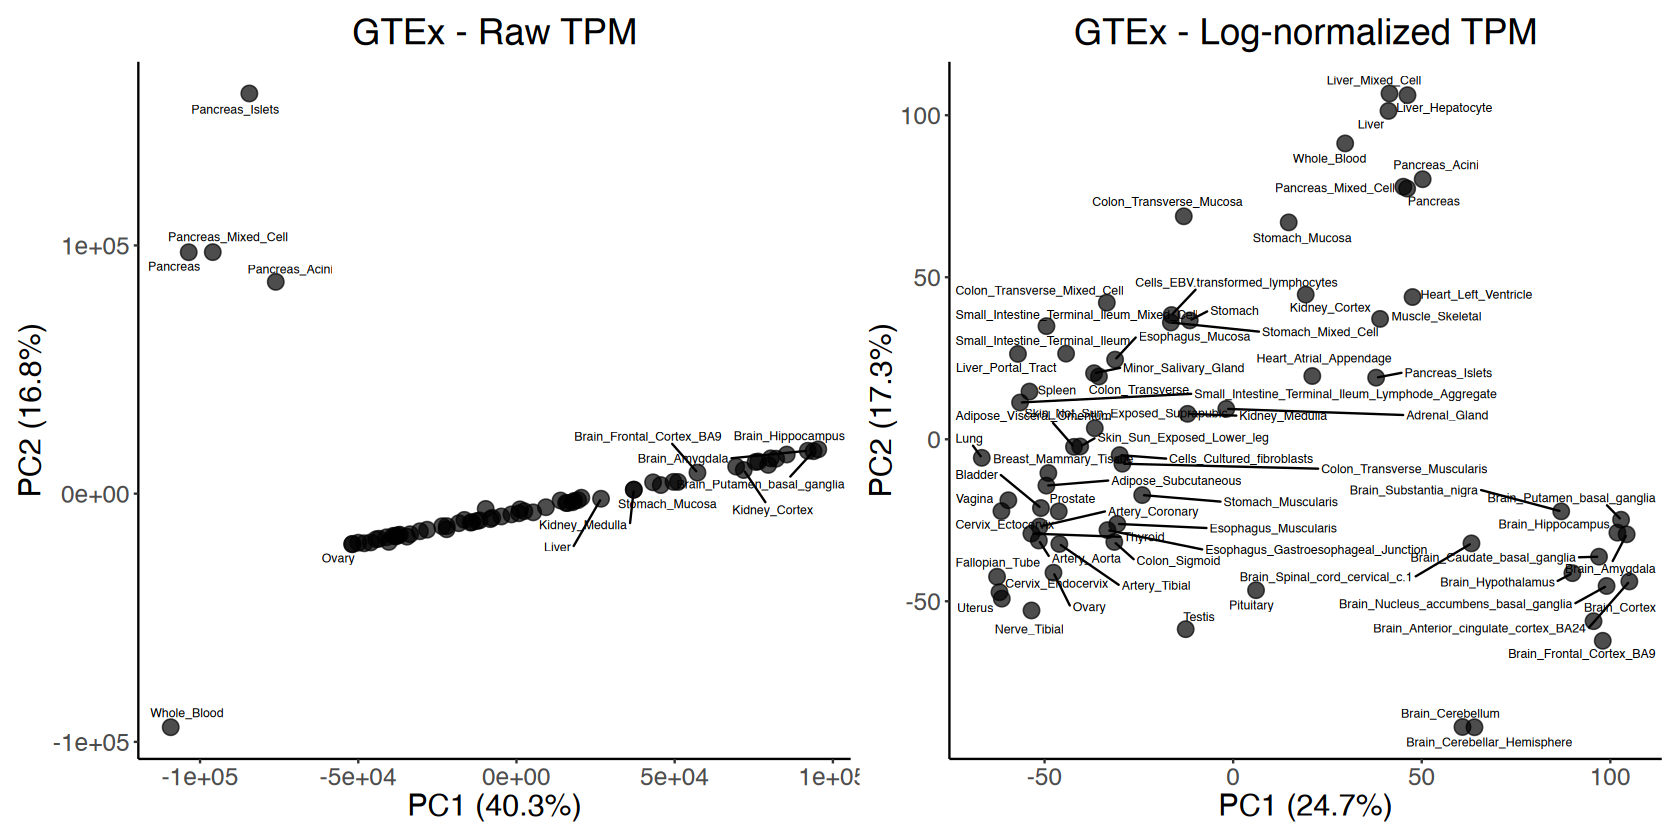

In [90]:
# Create combined plot
combined_plot <- p1 + p2

# change the size of the displayed plot
options(repr.plot.width=14, repr.plot.height=7)
print(combined_plot)

In [91]:
# Save the combined plot
ggsave(
    filename = file.path(out_dir, sprintf("GTEx_PCA_TPM_comparison_%s.pdf", date)),
    plot = combined_plot,
    width = width * 0.6,
    height = width * 0.3, 
    units = "in", 
    dpi = dpi
)

Warning message:
“ggrepel: 61 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


Create UMAP plot for the log normalized data

Running UMAP on first 10 PCs...



UMAP completed!


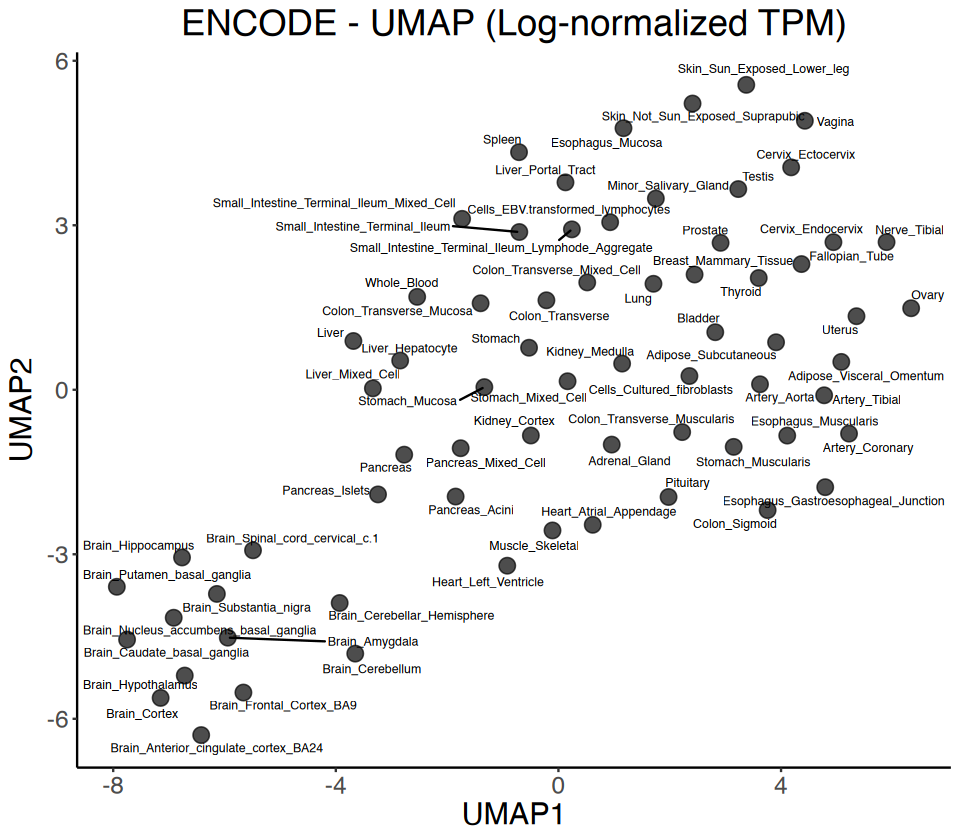

In [92]:
# Create UMAP plot for the log-normalized data
n_pcs <- 10
pca_data_for_umap <- pca_log$x[, 1:n_pcs]

cat("Running UMAP on first", n_pcs, "PCs...\n")
set.seed(seed)
# setup umap
umap_defaults <- umap.defaults
umap.defaults$n_neighbors <- 35
umap.defaults$min_dist <- 0.9
# umap.defaults$local_connectivity <- 0.1
# umap.defaults$spread <- 2
umap_result <- umap(pca_data_for_umap,config = umap.defaults)

# Create UMAP dataframe
umap_df <- data.frame(
  UMAP1 = umap_result$layout[, 1],
  UMAP2 = umap_result$layout[, 2],
  sample = sample_names
)

# Create UMAP plot
options(repr.plot.width=8, repr.plot.height=7)
p_umap <- ggplot(umap_df, aes(x = UMAP1, y = UMAP2, label = sample)) +
  geom_point(size = dot_size, alpha = 0.7) +
  ggrepel::geom_text_repel(size = 2.5, max.overlaps = 20, show.legend = FALSE, force = 10) +
  labs(
    title = "ENCODE - UMAP (Log-normalized TPM)",
    x = "UMAP1",
    y = "UMAP2"
  ) +
  theme_classic() +
  theme(
    text = element_text(size = text_size),
    plot.title = element_text(hjust = 0.5),
    legend.position = "none"
  )

print(p_umap)
cat("\nUMAP completed!\n")

In [94]:
# Save the combined plot
ggsave(
    filename = file.path(out_dir, sprintf("GTEx_UMAP_log_norm_PCA_%s.pdf", date)),
    plot = p_umap,
    width = width * 0.3,
    height = width * 0.3, 
    units = "in", 
    dpi = dpi
)